# Dimensionless diaphragm chain

A row of bistable diaphragms (each can sit in a "low" or "high" state) connected by
sealed gas pockets. Squeezing one pocket pushes on its neighbour through Boyle's law
(pressure x volume = constant), so a switch can travel along the row as a wave.

Written in dimensionless form, the whole model depends on just **four numbers**:

| group | what it is |
|-------|------------|
| **eta**   | gas pressure vs. how stiff each diaphragm is |
| **theta** | how much a gas pocket's volume changes when a diaphragm switches |
| **Pi**    | how lopsided the two states are - this is what drives the wave |
| **Omega** | damping |

The dimensional notebook already mapped what the raw knobs (A, delta, alpha) do one
at a time. This notebook is about the things you can *only* see with the groups:

- **same groups, same wave** - two builds with completely different raw numbers behave identically
- **different knobs, one curve** - sweeping p0, A or k is secretly the same sweep
- **width is set by one product** - eta and theta only ever act through eta*theta
- **squeeze vs stretch** - a gas-only effect, visible only when eta*theta is held fixed while theta varies

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# the four dimensionless groups (canonical values)
eta   = 80.0    # gas pressure / diaphragm stiffness
theta = 0.1     # volume change per switch
Pi    = 0.115   # asymmetry between the two states (drives the wave)
Omega = 10.0    # damping

print(f"eta={eta}, theta={theta}, Pi={Pi}, Omega={Omega}")

eta=80.0, theta=0.1, Pi=0.115, Omega=10.0


In [2]:
def wells(Pi):
    """The three rest states: roots of  u^3 - u + Pi = 0,  sorted low < mid < high."""
    r = np.sort(np.roots([1, 0, -1, Pi]).real)
    return r[0], r[1], r[2]

def gas_force(u, eta, theta):
    """Boyle-law pressure force on each diaphragm."""
    p = 1.0 / (1.0 + theta * (u[1:] - u[:-1]))     # 1 / volume of each gas pocket
    F = np.zeros_like(u)
    F[1:-1] = eta * (p[:-1] - p[1:])
    return F

def energy(u, v, eta, theta, Pi):
    """Total energy: motion + the double-well + the gas."""
    gaps = 1.0 + theta * (u[1:] - u[:-1])
    well = u**4/4 - u**2/2 + Pi*u
    return 0.5*np.sum(v**2) + np.sum(well) - (eta/theta)*np.sum(np.log(gaps))

def front_speed(frames, times, u_lo, u_hi, flip=False):
    """Track where the wave front is in each frame and fit its speed."""
    N = frames.shape[1]
    mid = 0.5*(u_lo + u_hi)
    pos = []
    for f in frames:
        sel = np.where(f < mid)[0] if not flip else np.where(f > mid)[0]
        if len(sel) == 0:
            pos.append(0.0)
        elif sel[-1] + 1 >= N:
            pos.append(float(sel[-1]))
        else:
            i = sel[-1]
            pos.append(i + (f[i] - mid) / (f[i] - f[i+1]))   # sub-diaphragm crossing
    pos = np.array(pos)
    half = times > 0.5*times[-1]                             # steady half only
    return (np.polyfit(times[half], pos[half], 1)[0] if half.sum() > 2 else np.nan), pos

def run(eta, theta, Pi, Omega, N=120, T=150.0, dt=None,
        n_sponge=10, sponge=4.0, n_trigger=5, save_every=200,
        track_energy=False, flip=False):
    """
    Integrate the chain and return the wave.

    Normally the left end is held low and the rest starts high; the boundary travels
    right as a wave. With flip=True the roles swap (left end high, rest low), which
    runs the mirrored wave. Returns a dict with frames, times, wave position and
    speed, or {'error': ...} if a gas pocket collapses.
    """
    if dt is None:
        dt = 0.05 / max(np.sqrt(2 + 4*abs(eta*theta)), Omega)
    u_lo, _, u_hi = wells(Pi)
    bg, trig = (u_hi, u_lo) if not flip else (u_lo, u_hi)

    # a little extra damping near the walls so the wave is absorbed, not reflected
    damp = np.full(N, float(Omega))
    if n_sponge > 0:
        ramp = sponge * ((n_sponge - np.arange(n_sponge)) / n_sponge)**2
        damp[:n_sponge]  += ramp
        damp[-n_sponge:] += ramp[::-1]

    u = np.full(N, bg); u[:n_trigger] = trig
    v = np.zeros(N)
    force = lambda uu: gas_force(uu, eta, theta) - (uu**3 - uu + Pi)

    steps = int(T / dt)
    frames, E = [], []
    a = force(u) - damp*v
    for step in range(steps):
        u += v*dt + 0.5*a*dt**2
        u[:n_trigger] = trig; u[-1] = bg
        v[:n_trigger] = 0.0;  v[-1] = 0.0
        if step > steps//10 and np.min(1 + theta*(u[1:]-u[:-1])) <= 0:
            return {'error': 'a gas pocket collapsed to zero volume'}
        f = force(u)
        v = (v + 0.5*dt*(a + f)) / (1 + 0.5*damp*dt)   # semi-implicit, handles damping
        v[:n_trigger] = 0.0; v[-1] = 0.0
        a = f - damp*v
        if step % save_every == 0:
            frames.append(u.copy())
            if track_energy: E.append(energy(u, v, eta, theta, Pi))

    frames = np.array(frames)
    times  = np.arange(len(frames)) * save_every * dt
    speed, pos = front_speed(frames, times, u_lo, u_hi, flip=flip)

    out = {'frames': frames, 'times': times, 'pos': pos, 'speed': speed,
           'u_lo': u_lo, 'u_hi': u_hi}
    if track_energy: out['energy'] = np.array(E)
    return out

print("simulator ready")

simulator ready


## A travelling wave

Hold the left end low and the right end high. The boundary between them moves along
the chain as a switching wave. Below it is shown at four moments in time.

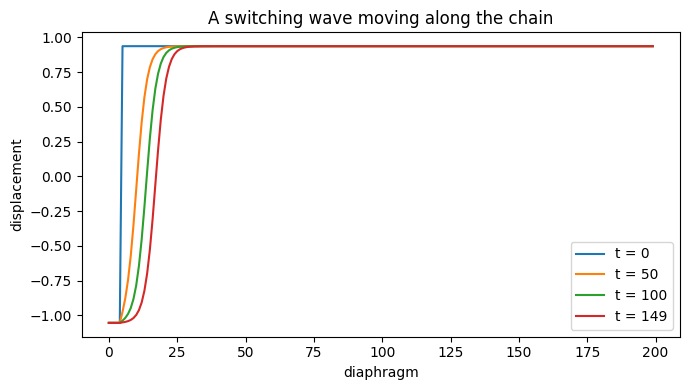

wave speed: 0.069 diaphragms per unit time


In [3]:
r = run(eta, theta, Pi, Omega, N=200, T=150)
sites = np.arange(r['frames'].shape[1])

plt.figure(figsize=(7, 4))
idx = [0, len(r['frames'])//3, 2*len(r['frames'])//3, len(r['frames'])-1]
for i in idx:
    plt.plot(sites, r['frames'][i], label=f"t = {r['times'][i]:.0f}")
plt.xlabel('diaphragm'); plt.ylabel('displacement')
plt.title('A switching wave moving along the chain')
plt.legend(); plt.tight_layout(); plt.show()

print(f"wave speed: {r['speed']:.3f} diaphragms per unit time")

## Same groups, same wave

Build two completely different physical systems - different masses, stiffnesses,
pressures and sizes - but chosen to share the *same* four groups. They produce the
exact same wave. This is the foundation everything else rests on.

raw physical parameters (deliberately very different):
                   m         k         a         A        p0        V0     delta     alpha
system A           1         1         1         1        80        10     0.115        10
system B       0.003       250      0.02    0.0005       320    0.0001   9.2e-07     0.173

four groups recovered from each set (target: 80, 0.1, 0.115, 10):
  system A:  eta=80.00   theta=0.100   Pi=0.1150   Omega=10.000
  system B:  eta=80.00   theta=0.100   Pi=0.1150   Omega=10.000

biggest difference between the three runs: 1.0e-14  -> identical wave


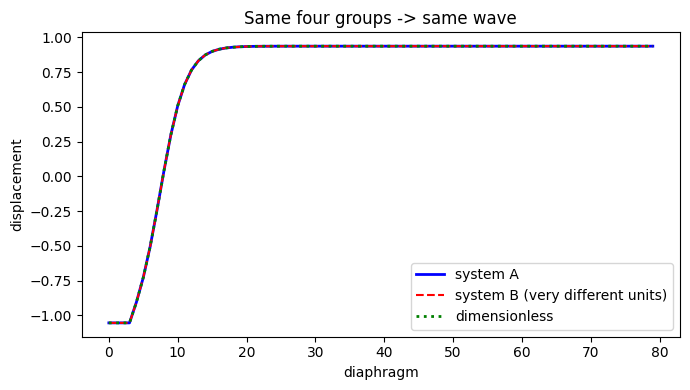

In [4]:
def dimensional_from_groups(eta, theta, Pi, Omega, m, k, a, A):
    """Physical parameters that reproduce the four groups (m, k, a, A are free choices)."""
    return dict(m=m, k=k, a=a, A=A,
                p0=eta*k*a**3/A, V0=A*a/theta, delta=Pi*a**3, alpha=Omega*a*np.sqrt(m*k))

def groups_from_dimensional(p):
    """Go the other way: recover (eta, theta, Pi, Omega) from physical parameters."""
    return (p['A']*p['p0']/(p['k']*p['a']**3), p['A']*p['a']/p['V0'],
            p['delta']/p['a']**3, p['alpha']/(p['a']*np.sqrt(p['m']*p['k'])))

def run_dimensional(m, A, k, p0, V0, a, delta, alpha,
                    N=80, T=60.0, dt_tilde=None, n_sponge=6, sponge=4.0,
                    n_trigger=4, save_every=100):
    """The same simulation in raw physical units. Returns (times, frames) with the
    output already rescaled, or None if a gas pocket collapses."""
    eta_ = A*p0/(k*a**3)
    Omega_ = alpha/(a*np.sqrt(m*k))
    if dt_tilde is None:
        dt_tilde = 0.05 / max(np.sqrt(2 + 4*abs(eta_*A*a/V0)), Omega_)
    T_scale = np.sqrt(m/(k*a**2))
    dt = dt_tilde * T_scale
    u_lo, _, u_hi = np.sort(np.roots([1, 0, -a**2, delta]).real)

    damp = np.full(N, float(alpha))
    if n_sponge > 0:
        ramp = sponge * a*np.sqrt(m*k) * ((n_sponge - np.arange(n_sponge)) / n_sponge)**2
        damp[:n_sponge]  += ramp
        damp[-n_sponge:] += ramp[::-1]

    u = np.full(N, u_hi); u[:n_trigger] = u_lo
    v = np.zeros(N)
    def force(uu):
        pr = p0*V0 / (V0 + A*(uu[1:] - uu[:-1]))
        F = np.zeros_like(uu); F[1:-1] = A*(pr[:-1] - pr[1:])
        return F - k*(uu**3 - a**2*uu + delta)

    steps = int(T*T_scale / dt)
    hist, acc = [], (force(u) - damp*v) / m
    for step in range(steps):
        u += v*dt + 0.5*acc*dt**2
        u[:n_trigger] = u_lo; u[-1] = u_hi; v[:n_trigger] = 0; v[-1] = 0
        if step > steps//10 and np.min(V0 + A*(u[1:] - u[:-1])) <= 0:
            return None                                    # pocket collapsed
        f = force(u)
        v = (v + 0.5*dt*(acc + f/m)) / (1 + 0.5*damp*dt/m)
        v[:n_trigger] = 0; v[-1] = 0
        acc = (f - damp*v) / m
        if step % save_every == 0:
            hist.append(u / a)              # divide by length scale -> same units as run()
    return np.arange(len(hist)) * save_every * dt_tilde, np.array(hist)

# two genuinely different physical builds, both tuned to the same four groups
A_sys = dimensional_from_groups(eta, theta, Pi, Omega, m=1.0,  k=1.0,   a=1.0,  A=1.0)
B_sys = dimensional_from_groups(eta, theta, Pi, Omega, m=3e-3, k=250.0, a=0.02, A=5e-4)

cols = ['m', 'k', 'a', 'A', 'p0', 'V0', 'delta', 'alpha']
print("raw physical parameters (deliberately very different):")
print("          " + "".join(f"{c:>10}" for c in cols))
for name, p in [('system A', A_sys), ('system B', B_sys)]:
    print(f"{name:10}" + "".join(f"{p[c]:>10.3g}" for c in cols))

print("\nfour groups recovered from each set (target: 80, 0.1, 0.115, 10):")
for name, p in [('system A', A_sys), ('system B', B_sys)]:
    e, t, pi, om = groups_from_dimensional(p)
    print(f"  {name}:  eta={e:.2f}   theta={t:.3f}   Pi={pi:.4f}   Omega={om:.3f}")

# run both physical systems and the dimensionless one; they should coincide
dt0 = 0.05 / max(np.sqrt(2 + 4*eta*theta), Omega)
kw  = dict(N=80, T=60.0, dt_tilde=dt0, n_sponge=6, n_trigger=4, save_every=100)
tA, hA = run_dimensional(**A_sys, **kw)
tB, hB = run_dimensional(**B_sys, **kw)
hD = run(eta, theta, Pi, Omega, N=80, T=60.0, dt=dt0,
         n_sponge=6, n_trigger=4, save_every=100)['frames']

n    = min(len(hA), len(hB), len(hD))
diff = max(np.max(np.abs(hA[:n]-hB[:n])), np.max(np.abs(hA[:n]-hD[:n])))
print(f"\nbiggest difference between the three runs: {diff:.1e}  ->",
      "identical wave" if diff < 1e-8 else "MISMATCH")

mid = n // 2
plt.figure(figsize=(7, 4))
plt.plot(hA[mid], 'b-',  lw=2,   label='system A')
plt.plot(hB[mid], 'r--', lw=1.5, label='system B (very different units)')
plt.plot(hD[mid], 'g:',  lw=2,   label='dimensionless')
plt.xlabel('diaphragm'); plt.ylabel('displacement')
plt.title('Same four groups -> same wave'); plt.legend(); plt.tight_layout(); plt.show()

## Check: the simulation is sound

Turn the damping off (Omega = 0). With no damping the total energy should stay flat -
a basic check that the integrator is behaving and not quietly adding or losing energy.

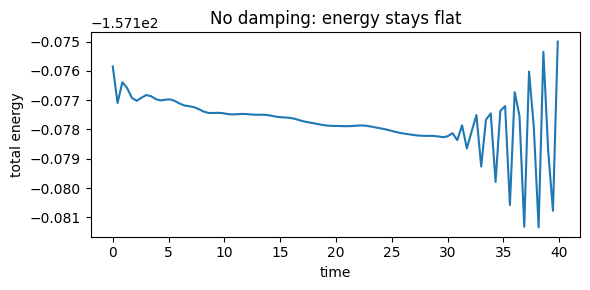

largest energy drift: 3.5e-05  (should be near zero)


In [5]:
r0 = run(eta, theta, Pi, 0.0, N=80, T=40, n_sponge=0, n_trigger=4,
         save_every=50, track_energy=True)
E = r0['energy']
drift = np.max(np.abs((E - E[0]) / abs(E[0])))

plt.figure(figsize=(6, 3))
plt.plot(r0['times'][:len(E)], E)
plt.xlabel('time'); plt.ylabel('total energy')
plt.title('No damping: energy stays flat'); plt.tight_layout(); plt.show()

print(f"largest energy drift: {drift:.1e}  (should be near zero)")

## Different knobs, one curve

In raw units the input pressure p0, the diaphragm area A and the stiffness k look
like three separate knobs. The groups say otherwise: the wave feels all of them only
through eta.

Three sweeps in raw physical units: turn up p0; turn up A (pocket volume scaled with
it so theta stays put); turn down k (damper scaled with it so Omega stays put). The
raw speeds disagree - the k sweep barely seems to do anything at all, while the
p0 and A sweeps land exactly on top of each other (both knobs only move eta). Rescale time
and every point lands on the same dimensionless curve. Three experiments, one law.

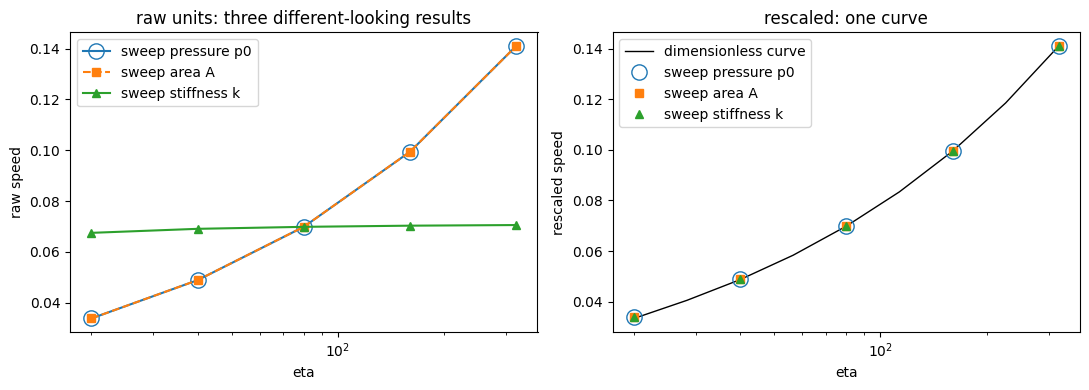

largest gap between the three sweeps and the dimensionless curve: 4.0e-04


In [6]:
# the one dimensionless curve: speed against eta, all else fixed
master_eta = np.geomspace(20, 320, 9)
master_c   = [run(e, theta, Pi, Omega, N=100, T=100)['speed'] for e in master_eta]

u_lo0, _, u_hi0 = wells(Pi)
def dim_speed(**build):
    """Wave speed of a raw physical build, in rescaled units."""
    t, h = run_dimensional(**build, N=100, T=100)
    return front_speed(h, t, u_lo0, u_hi0)[0]

# sweep 1: pressure p0 (eta = p0 here since A = k = a = 1)
sw_p0 = [(p0, 1.0, dim_speed(m=1, A=1, k=1, p0=p0, V0=10, a=1, delta=0.115, alpha=10))
         for p0 in [20, 40, 80, 160, 320]]
# sweep 2: area A, with V0 = 10*A so theta stays 0.1  (eta = 80*A)
sw_A  = [(80*A_, 1.0, dim_speed(m=1, A=A_, k=1, p0=80, V0=10*A_, a=1, delta=0.115, alpha=10))
         for A_ in [0.25, 0.5, 1, 2, 4]]
# sweep 3: stiffness k, with alpha = 10*sqrt(k) so Omega stays 10  (eta = 80/k)
# time scale is 1/sqrt(k), so the raw speed differs from the rescaled one
sw_k  = [(80/k_, 1/np.sqrt(k_), dim_speed(m=1, A=1, k=k_, p0=80, V0=10, a=1, delta=0.115,
                                          alpha=10*np.sqrt(k_)))
         for k_ in [4, 2, 1, 0.5, 0.25]]

# note: the p0 and A sweeps give exactly the same numbers (both knobs only move
# eta), so their points sit right on top of each other - open/filled markers of
# different sizes keep both visible
styles = [(sw_p0, dict(marker='o', ms=11, mfc='none', color='tab:blue',  ls='-'),  'sweep pressure p0'),
          (sw_A,  dict(marker='s', ms=6,             color='tab:orange', ls='--'), 'sweep area A'),
          (sw_k,  dict(marker='^', ms=6,             color='tab:green',  ls='-'),  'sweep stiffness k')]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
for sw, st, lab in styles:
    e   = [x[0] for x in sw]
    raw = [x[2]/x[1] for x in sw]          # speed in raw time units
    ax1.plot(e, raw, label=lab, **st)
ax1.set_xscale('log'); ax1.set_xlabel('eta'); ax1.set_ylabel('raw speed')
ax1.set_title('raw units: three different-looking results'); ax1.legend()

ax2.plot(master_eta, master_c, 'k-', lw=1, label='dimensionless curve')
for sw, st, lab in styles:
    e  = [x[0] for x in sw]
    ct = [x[2] for x in sw]                # speed in rescaled (wave) units
    ax2.plot(e, ct, label=lab, **{**st, 'ls': 'none'})
ax2.set_xscale('log'); ax2.set_xlabel('eta'); ax2.set_ylabel('rescaled speed')
ax2.set_title('rescaled: one curve'); ax2.legend()
plt.tight_layout(); plt.show()

# the sweeps hit the same eta values as the curve at indices 0, 2, 4, 6, 8
ref = np.array(master_c)[[0, 2, 4, 6, 8]]
gap = max(np.max(np.abs([x[2] for x in sw] - ref)) for sw in [sw_p0, sw_A, sw_k])
print(f"largest gap between the three sweeps and the dimensionless curve: {gap:.1e}")

## Front width is set by one product

The wave front is spread over several diaphragms. How many? Only the product
eta*theta matters - in raw units that product mixes pressure, area, stiffness, size
and pocket volume, five knobs acting as one number. The width grows like the square
root of eta*theta.

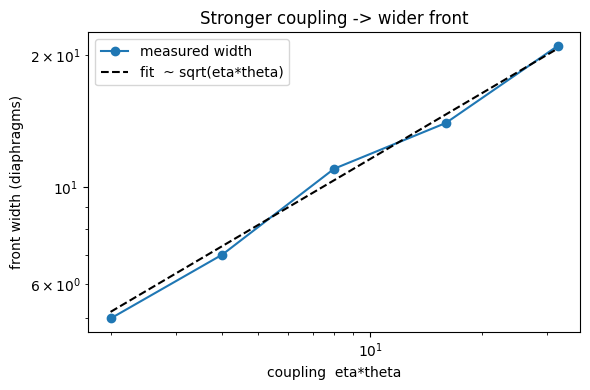

eta*theta =  2   ->   width = 5 diaphragms
eta*theta =  4   ->   width = 7 diaphragms
eta*theta =  8   ->   width = 11 diaphragms
eta*theta = 16   ->   width = 14 diaphragms
eta*theta = 32   ->   width = 21 diaphragms


In [7]:
def kink_width(frame, u_lo, u_hi):
    """Number of diaphragms caught mid-switch (between the two states)."""
    eps    = 0.05 * (u_hi - u_lo)
    inside = (frame > u_lo + eps) & (frame < u_hi - eps)
    c = int(np.argmax(np.abs(np.gradient(frame))))       # steepest point
    l = c
    while l > 0 and inside[l-1]: l -= 1
    r = c
    while r < len(frame)-1 and inside[r+1]: r += 1
    return r - l + 1

theta_w = 0.05                                            # small theta, cleaner fronts
couplings, widths = [2, 4, 8, 16, 32], []
for kap in couplings:
    r = run(kap/theta_w, theta_w, Pi, 15.0, N=200, T=120,
            n_sponge=12, sponge=8, n_trigger=5, save_every=300)
    frame = r['frames'][len(r['frames'])//2]
    widths.append(kink_width(frame, r['u_lo'], r['u_hi']))

kap = np.array(couplings, float); w = np.array(widths, float)
c   = np.sum(w * np.sqrt(kap)) / np.sum(kap)              # fit  width = c*sqrt(eta*theta)

plt.figure(figsize=(6, 4))
plt.plot(kap, w, 'o-', label='measured width')
plt.plot(kap, c*np.sqrt(kap), 'k--', label='fit  ~ sqrt(eta*theta)')
plt.xscale('log'); plt.yscale('log')
plt.xlabel('coupling  eta*theta'); plt.ylabel('front width (diaphragms)')
plt.title('Stronger coupling -> wider front'); plt.legend(); plt.tight_layout(); plt.show()

for k_, wi in zip(couplings, widths):
    print(f"eta*theta = {k_:2d}   ->   width = {wi} diaphragms")

## Squeeze vs stretch: the gas fingerprint

A wave can pass in two mirrored ways: one squeezes the gas pockets as it goes, the
other stretches them. For a chain joined by plain springs the two are exactly equal.
The gas is not a spring: Boyle's law is lopsided - squeezing a pocket raises its
pressure by more than stretching lowers it - so the squeezing wave travels faster.

The test only makes sense in group language: hold the coupling eta*theta fixed and
turn up theta alone. In raw units that means retuning pressure and pocket volume
together - a sweep you would never find from the raw parameters. As theta goes to
zero the gas turns into a spring and the two speeds merge; as theta grows the gap
opens up. (The mirrored wave = flip the sign of Pi and start from the opposite state.)

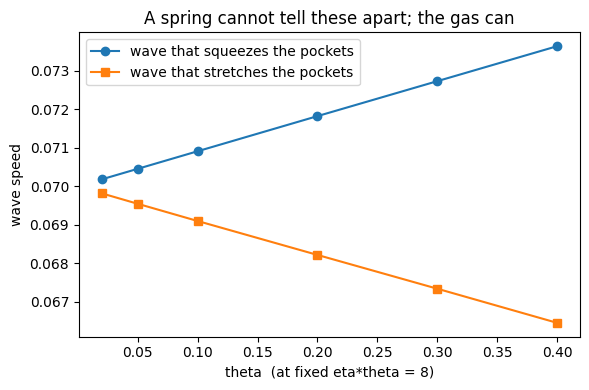

theta   squeeze   stretch   gap
0.02    0.0702    0.0698   +0.5%
0.05    0.0705    0.0695   +1.3%
0.10    0.0709    0.0691   +2.6%
0.20    0.0718    0.0682   +5.3%
0.30    0.0727    0.0673   +8.0%
0.40    0.0736    0.0665   +10.8%


In [8]:
kap = 8.0                                              # eta*theta held fixed
th_vals   = [0.02, 0.05, 0.1, 0.2, 0.3, 0.4]
c_stretch = [run(kap/t, t, +Pi, Omega, N=150, T=120)['speed'] for t in th_vals]
c_squeeze = [run(kap/t, t, -Pi, Omega, N=150, T=120, flip=True)['speed'] for t in th_vals]

plt.figure(figsize=(6, 4))
plt.plot(th_vals, c_squeeze, 'o-', label='wave that squeezes the pockets')
plt.plot(th_vals, c_stretch, 's-', label='wave that stretches the pockets')
plt.xlabel('theta  (at fixed eta*theta = 8)'); plt.ylabel('wave speed')
plt.title('A spring cannot tell these apart; the gas can')
plt.legend(); plt.tight_layout(); plt.show()

print("theta   squeeze   stretch   gap")
for t, cq, cs in zip(th_vals, c_squeeze, c_stretch):
    print(f"{t:.2f}    {cq:.4f}    {cs:.4f}   {100*(cq-cs)/cs:+.1f}%")

## Summary

Working in the four groups instead of the eight raw parameters bought four things:

1. **One model, every build** - any two physical systems with the same (eta, theta, Pi, Omega)
   produce the same wave, checked here to 14 decimal places.
2. **Fewer experiments** - sweeps of p0, A and k all trace the same curve against eta;
   one dimensionless sweep replaces them all.
3. **A width law** - the front width grows as the square root of the single product eta*theta,
   which stands in for five raw knobs.
4. **New physics** - the squeeze/stretch speed asymmetry is invisible in raw parameters but
   appears as soon as theta is varied at fixed eta*theta. It is the clearest signature that
   the coupling is a gas and not a spring.

(The dimensional groundwork - the integrator checks, the Arrieta formula's validity region,
and the ringing physics - is in `diaphragm_metafluid.ipynb`.)